In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
import glob
import numpy as np
import scienceplots
plt.style.use(['science','notebook','grid'])

In [2]:

file_path = '/home/shin101/cluster_mount/scripts/qm_qd_hel_age_bias_v2'
results = {}


In [3]:
glob.glob(f"{file_path}/*_*.txt")

[]

In [3]:
all_dfs =[]
for path in glob.glob(f"{file_path}/*_*.txt"):
    df = pd.read_csv(path,sep=',', header=None)
    all_dfs.append(df)
df = pd.concat(all_dfs, ignore_index=True)


ValueError: No objects to concatenate

In [4]:
def update_master(file_path, master_file):
    # Load existing master if it exists
    if os.path.exists(master_file):
        master_df = pd.read_csv(master_file)
    else:
        master_df = pd.DataFrame()

    # Find new files
    paths = glob.glob(f"{file_path}/*_*.txt")
    new_dfs = []

    for path in paths:
        df = pd.read_csv(path, header=None)
        new_dfs.append(df)

        # delete after reading
        try:
            os.remove(path)
        except Exception as e:
            print(f"Could not delete {path}: {e}")

    # If there are no new files, just return master as is
    if not new_dfs:
        return master_df

    # Append new data
    new_data = pd.concat(new_dfs, ignore_index=True)
    updated = pd.concat([master_df, new_data], ignore_index=True)

    # Save back to master file
    updated.to_csv(master_file, index=False)

    return updated
import os

In [5]:
df = update_master('/home/shin101/cluster_mount/scripts/','/home/shin101/cluster_mount/scripts/combined_results.txt')


In [6]:
df

,0,1,2,3,4,5
0,0,-0.127966,-15.000000,-143.934673,True,0.01044
1,0,-0.146610,-10.423729,-153.734727,True,0.01044
2,0,-0.444915,-11.186441,-107.745972,True,0.01044
3,0,0.431356,-8.135593,-172.543684,True,0.01044
4,0,0.151695,-14.237288,-163.766361,True,0.01044
...,...,...,...,...,...,...
3595,0,-0.034746,-7.372881,-170.846157,True,0.01044
3596,0,-0.277119,-6.610169,-145.412940,True,0.01044
3597,0,0.226271,-8.898305,-177.694043,True,0.01044
3598,0,0.021186,-7.372881,-174.711580,True,0.01044


In [42]:
df

,0,1,2,3,4,5
0,10,-0.005085,0.644068,-146.240096,True,0.048692
1,10,-0.005085,10.338983,-169.505842,True,0.016360
2,10,-0.005085,11.220339,-169.907044,True,0.015627
3,10,-0.005085,12.101695,-170.245484,True,0.014985
4,10,-0.005085,12.983051,-170.531583,True,0.014418
...,...,...,...,...,...,...
3190,10,-0.600000,4.169492,-54.880703,True,0.026103
3191,10,-0.600000,5.932203,-58.120280,True,0.021903
3192,10,-0.600000,6.813559,-59.275507,True,0.020340
3193,10,-0.600000,7.694915,-60.229807,True,0.019042


In [ ]:
np.argsort()

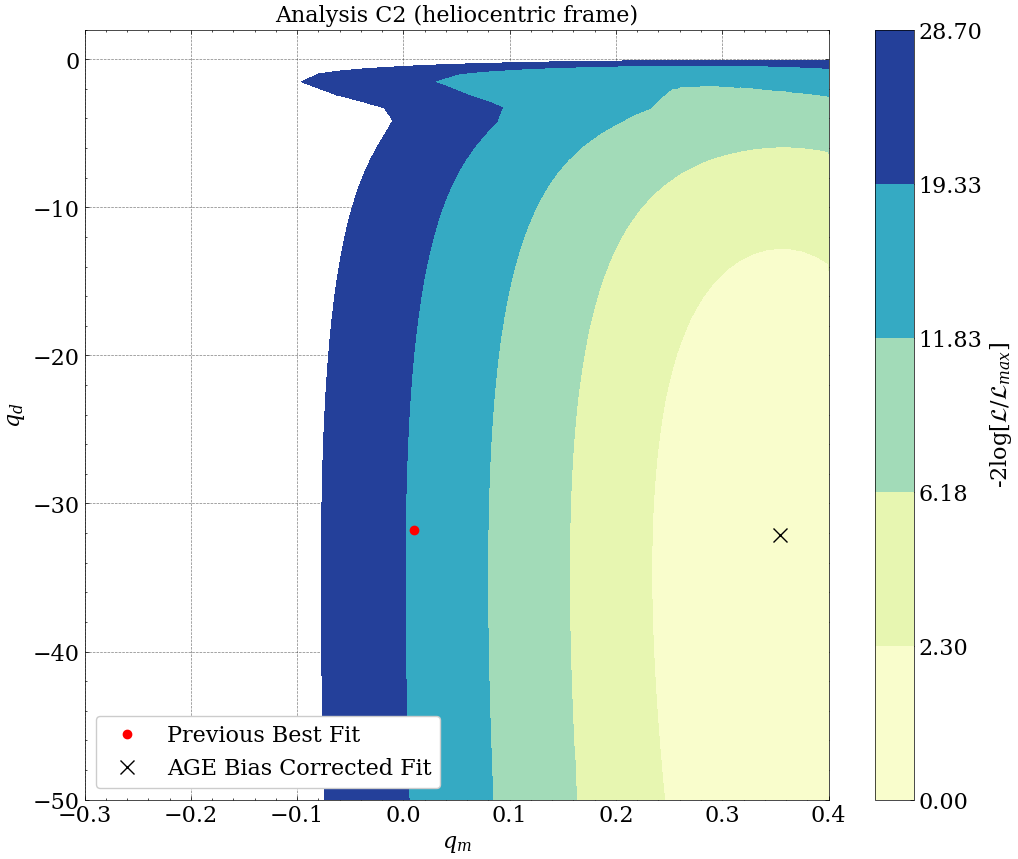

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['notebook','science'])
plt.rcParams["text.usetex"] = False
df = pd.read_csv('/home/shin101/cluster_mount/scripts/qm_qd_hel_age_bias_v2/combined_results_v3.csv',header=None)
contour = ax.tricontourf(df[1], df[2], df[3]-np.min(df[3]), levels=[0,2.3,6.18,11.83,19.33,28.7], cmap='YlGnBu')
qm_previous = 0.01
qd_previous = -31.8
qm_new = 3.540e-01
qd_new = -32.1
plt.plot(qm_previous, qd_previous, 'o', color='red', markersize=6, label='Previous Best Fit')
plt.plot(qm_new, qd_new,'x', color='black', markersize=10, label='AGE Bias Corrected Fit')
#plt.plot(df[1], df[2], 'k.', markersize=2)
ax.set_ylim(-50,2)
ax.set_xlim(-0.3,0.4)
plt.legend(frameon=True,loc='lower left')
fig.colorbar(contour, ax=ax, label=r'-2log[$\mathcal{L}/\mathcal{L}_{max}$]')
ax.set_xlabel('$q_m$')
ax.set_ylabel('$q_d$')
ax.set_title('Analysis C2 (heliocentric frame)')
#ax.plot(df[1], df[2], 'k.', markersize=2, label='Data Points')
plt.show()

In [11]:
np.unique(df[1],return_counts=True)

(array([-0.6       , -0.58148148, -0.56296296, -0.54444444, -0.52592593,
        -0.50740741, -0.48888889, -0.47037037, -0.45185185, -0.43333333,
        -0.41481481, -0.3962963 , -0.37777778, -0.35925926, -0.34074074,
        -0.32222222, -0.3037037 , -0.28518519, -0.26666667, -0.24814815,
        -0.22962963, -0.21111111, -0.19259259, -0.17407407, -0.15555556,
        -0.13703704, -0.11851852, -0.1       , -0.08148148, -0.06296296,
        -0.04444444, -0.02592593, -0.00740741,  0.01111111,  0.02962963,
         0.04814815,  0.06666667,  0.08518519,  0.1037037 ,  0.12222222,
         0.14074074,  0.15925926,  0.17777778,  0.1962963 ,  0.21481481,
         0.23333333,  0.25185185,  0.27037037,  0.28888889,  0.30740741,
         0.32592593,  0.34444444,  0.36296296,  0.38148148,  0.4       ,
         1.        ]),
 array([55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55,
        55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55,
        55, 55, 55, 55

In [10]:
np.unique(df[2],return_counts=True)

(array([-2.        , -1.03703704, -0.07407407,  0.88888889,  1.85185185,
         2.        ,  2.81481481,  3.77777778,  4.74074074,  5.7037037 ,
         6.66666667,  7.62962963,  8.59259259,  9.55555556, 10.51851852,
        11.48148148, 12.44444444, 13.40740741, 14.37037037, 15.33333333,
        16.2962963 , 17.25925926, 18.22222222, 19.18518519, 20.14814815,
        21.11111111, 22.07407407, 23.03703704, 24.        , 24.96296296,
        25.92592593, 26.88888889, 27.85185185, 28.81481481, 29.77777778,
        30.74074074, 31.7037037 , 32.66666667, 33.62962963, 34.59259259,
        35.55555556, 36.51851852, 37.48148148, 38.44444444, 39.40740741,
        40.37037037, 41.33333333, 42.2962963 , 43.25925926, 44.22222222,
        45.18518519, 46.14814815, 47.11111111, 48.07407407, 49.03703704,
        50.        ]),
 array([55, 55, 55, 55, 55,  1, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55,
        55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55, 55,
        55, 55, 55, 55

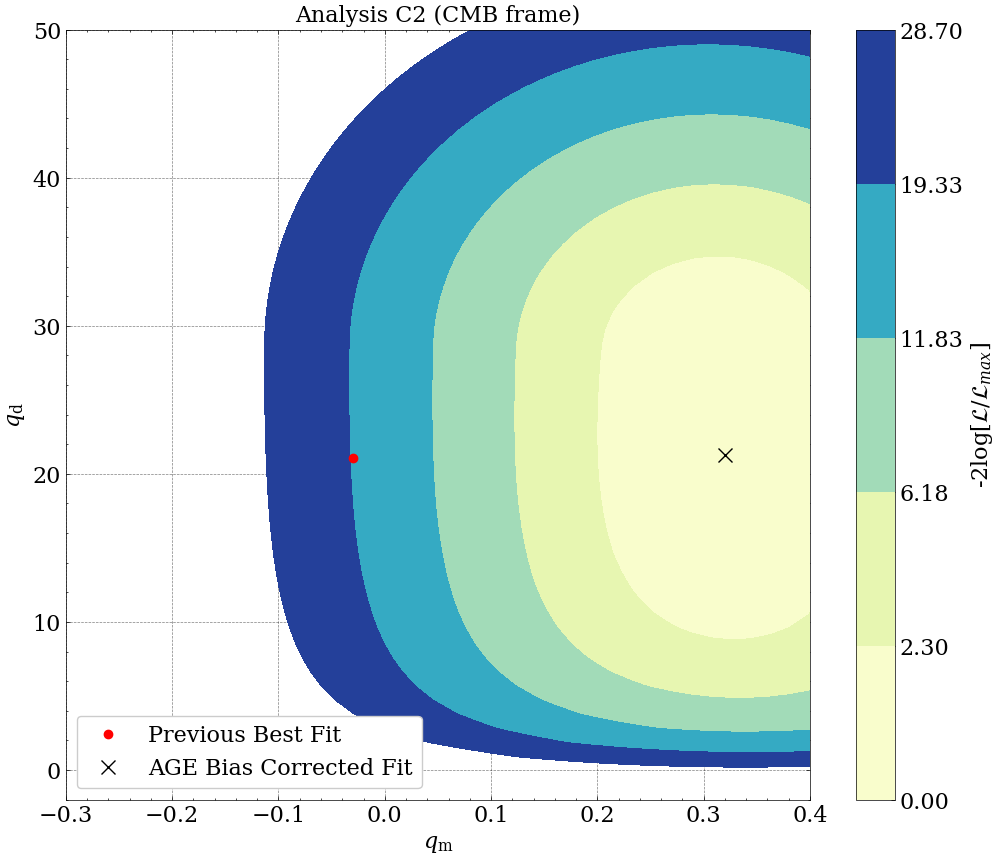

In [14]:
df = pd.read_csv('/home/shin101/cluster_mount/scripts/qm_qd_CMB_age_bias_v2/combined_results.txt',header=None)
df=df.iloc[:]
fig, ax = plt.subplots(figsize=(12, 10))
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['notebook','science'])
plt.rcParams["text.usetex"] = False
contour = ax.tricontourf(df[1], df[2], df[3]-np.min(df[3]), levels=[0,2.3,6.18,11.83,19.33,28.7], cmap='YlGnBu')
qm_previous = -0.03
qd_previous = 21.1
# qm_new = 3.540e-01
# qd_new = -32.1
qm_new = 3.204e-01
qd_new = 2.127e+01
plt.plot(qm_previous, qd_previous, 'o', color='red', markersize=6, label='Previous Best Fit')
plt.plot(qm_new, qd_new,'x', color='black', markersize=10, label='AGE Bias Corrected Fit')
#plt.plot(df[1], df[2], 'k.', markersize=2)
ax.set_ylim(-2,50)
ax.set_xlim(-0.3,0.4)
plt.legend(frameon=True,loc='lower left')
fig.colorbar(contour, ax=ax, label=r'-2log[$\mathcal{L}/\mathcal{L}_{max}$]')
ax.set_xlabel(r'$q_{\text{m}}$')
ax.set_ylabel(r'$q_{\text{d}}$')
ax.set_title('Analysis C2 (CMB frame)')
#ax.plot(df[1], df[2], 'k.', markersize=2, label='Data Points')
plt.show()

In [72]:
import pandas as pd
df = pd.read_csv('/home/shin101/cluster_mount/scripts/qm_qd_CMB_age_bias/combined_results.csv', header=None)
df_cleaned = df.dropna(axis=1, how='all')
df_cleaned = df_cleaned.dropna(axis=0, how='all')
df_cleaned.to_csv('cleaned_results.csv', index=False, header=False)
print(f"Cleaned! Processed {len(df_cleaned)} rows")
df_cleaned

Cleaned! Processed 4796 rows


,0,1,2,3,4,5,6,7,8,9,10,11
0,0.0,1.000000,2.000000,3.000000,4,5.000000,0.0,1.0,2.000000,3.000000,4,5.000000
1,10.0,-0.005085,0.644068,-146.240096,True,0.048692,NaN,NaN,NaN,NaN,NaN,NaN
2,10.0,-0.005085,10.338983,-169.505842,True,0.016360,NaN,NaN,NaN,NaN,NaN,NaN
3,10.0,-0.005085,11.220339,-169.907044,True,0.015627,NaN,NaN,NaN,NaN,NaN,NaN
4,10.0,-0.005085,12.101695,-170.245484,True,0.014985,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
4791,NaN,NaN,NaN,NaN,NaN,NaN,10.0,0.4,50.000000,-165.653544,True,0.009580
4792,NaN,NaN,NaN,NaN,NaN,NaN,10.0,0.4,5.692308,-182.506230,True,0.023672
4793,NaN,NaN,NaN,NaN,NaN,NaN,10.0,0.4,6.923077,-183.774348,True,0.020916
4794,NaN,NaN,NaN,NaN,NaN,NaN,10.0,0.4,8.153846,-184.705257,True,0.018917


In [73]:
df

,0,1,2,3,4,5,6,7,8,9,10,11
0,0.0,1.000000,2.000000,3.000000,4,5.000000,0.0,1.0,2.000000,3.000000,4,5.000000
1,10.0,-0.005085,0.644068,-146.240096,True,0.048692,NaN,NaN,NaN,NaN,NaN,NaN
2,10.0,-0.005085,10.338983,-169.505842,True,0.016360,NaN,NaN,NaN,NaN,NaN,NaN
3,10.0,-0.005085,11.220339,-169.907044,True,0.015627,NaN,NaN,NaN,NaN,NaN,NaN
4,10.0,-0.005085,12.101695,-170.245484,True,0.014985,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
4791,NaN,NaN,NaN,NaN,NaN,NaN,10.0,0.4,50.000000,-165.653544,True,0.009580
4792,NaN,NaN,NaN,NaN,NaN,NaN,10.0,0.4,5.692308,-182.506230,True,0.023672
4793,NaN,NaN,NaN,NaN,NaN,NaN,10.0,0.4,6.923077,-183.774348,True,0.020916
4794,NaN,NaN,NaN,NaN,NaN,NaN,10.0,0.4,8.153846,-184.705257,True,0.018917


In [7]:
df = pd.read_csv('/home/shin101/cluster_mount/scripts/qm_qd_LG_age_bias/combined_results.txt',header=None)

In [21]:
np.argmin(df[3])
df[[1,2]].iloc[2084]

1     0.307627
2   -61.932203
Name: 2084, dtype: float64

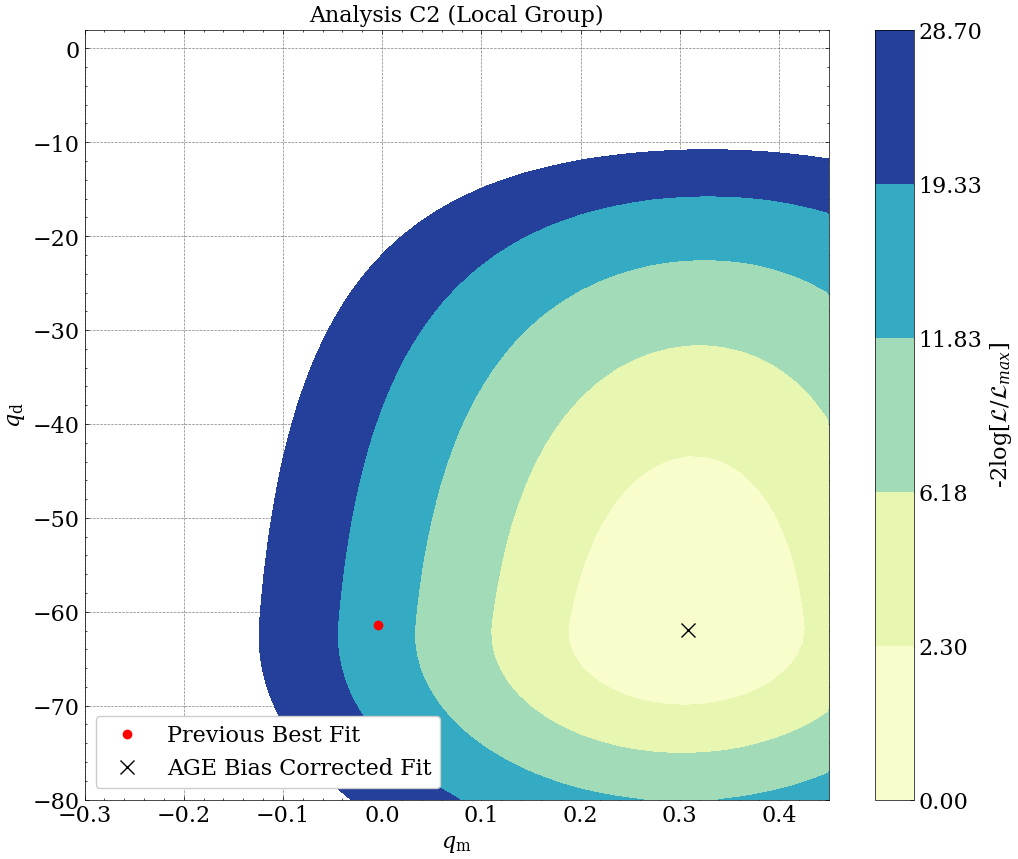

In [23]:
df = pd.read_csv('/home/shin101/cluster_mount/scripts/qm_qd_LG_age_bias/combined_results.txt',header=None)
df=df.iloc[:]
fig, ax = plt.subplots(figsize=(12, 10))
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['notebook','science'])
plt.rcParams["text.usetex"] = False
contour = ax.tricontourf(df[1], df[2], df[3]-np.min(df[3]), levels=[0,2.3,6.18,11.83,19.33,28.7], cmap='YlGnBu')
qm_previous = -0.0038
qd_previous = -61.4
qm_new = 0.308
qd_new = -61.93
# qm_new = 3.204e-01
# qd_new = 2.127e+01
plt.plot(qm_previous, qd_previous, 'o', color='red', markersize=6, label='Previous Best Fit')
plt.plot(qm_new, qd_new,'x', color='black', markersize=10, label='AGE Bias Corrected Fit')
#plt.plot(df[1], df[2], 'k.', markersize=2)
# ax.set_ylim(-2,50)
ax.set_xlim(-0.3,0.45)
plt.legend(frameon=True,loc='lower left')
fig.colorbar(contour, ax=ax, label=r'-2log[$\mathcal{L}/\mathcal{L}_{max}$]')
ax.set_xlabel(r'$q_{\text{m}}$')
ax.set_ylabel(r'$q_{\text{d}}$')
ax.set_title('Analysis C2 (Local Group)')
#ax.plot(df[1], df[2], 'k.', markersize=2, label='Data Points')
plt.show()

/tmp/ipykernel_309398/3818185225.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=True,loc='lower left')


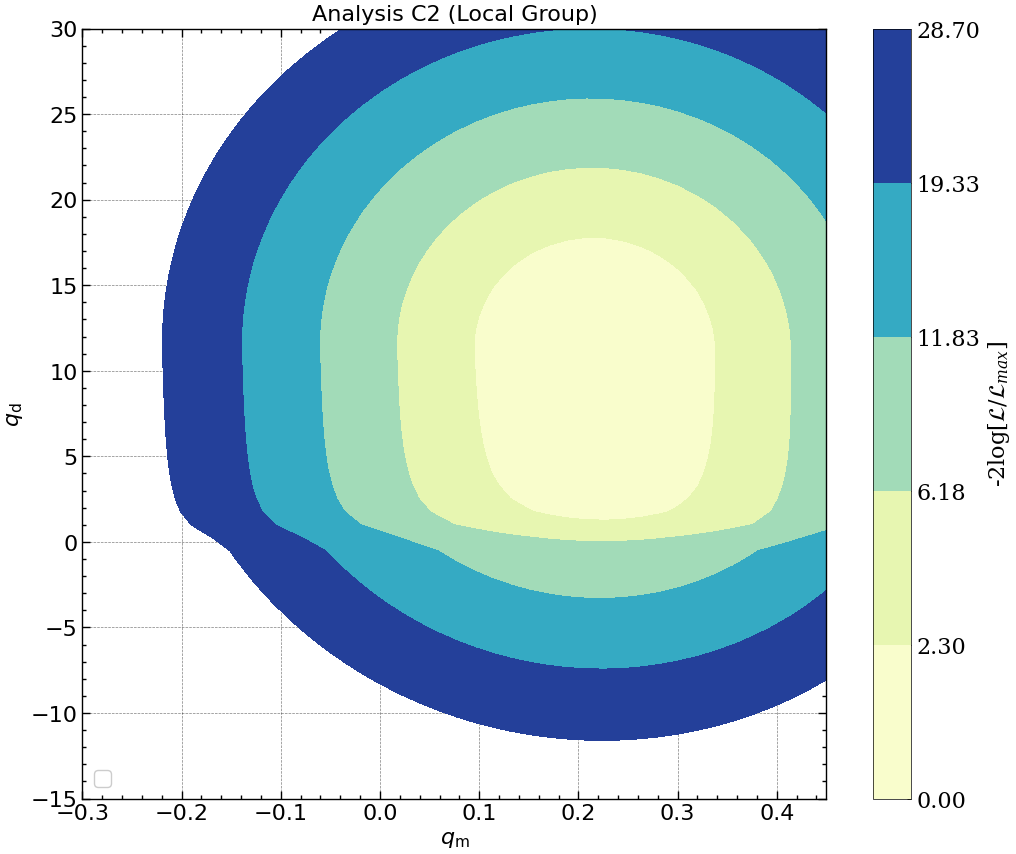

In [7]:
df=df.iloc[:]
fig, ax = plt.subplots(figsize=(12, 10))
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['notebook','science'])
plt.rcParams["text.usetex"] = False
contour = ax.tricontourf(df[1], df[2], df[3]-np.min(df[3]), levels=[0,2.3,6.18,11.83,19.33,28.7], cmap='YlGnBu')
# qm_previous = -0.0038
# qd_previous = -61.4
# qm_new = 0.308
# qd_new = -61.93
# qm_new = 3.204e-01
# qd_new = 2.127e+01
# plt.plot(qm_previous, qd_previous, 'o', color='red', markersize=6, label='Previous Best Fit')
# plt.plot(qm_new, qd_new,'x', color='black', markersize=10, label='AGE Bias Corrected Fit')
#plt.plot(df[1], df[2], 'k.', markersize=2)
# ax.set_ylim(-2,50)
ax.set_xlim(-0.3,0.45)
plt.legend(frameon=True,loc='lower left')
fig.colorbar(contour, ax=ax, label=r'-2log[$\mathcal{L}/\mathcal{L}_{max}$]')
ax.set_xlabel(r'$q_{\text{m}}$')
ax.set_ylabel(r'$q_{\text{d}}$')
ax.set_title('Analysis C2 (Local Group)')
#ax.plot(df[1], df[2], 'k.', markersize=2, label='Data Points')
plt.show()